# Seoul Bike Demand Prediction — LightGBM optimized for RMSLE

This notebook uses log-transformed demand, 5-fold randomized hyperparameter search, and additional temporal/weather interaction features including rush hour, working hour, hour × working day, hour × season, temperature × hour, and humidity × hour.

In [1]:
# 1. Imports and configuration
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, GridSearchCV, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error, r2_score

warnings.filterwarnings("ignore")

BASE_DIR = os.getcwd()
TRAIN_PATH = os.path.join(BASE_DIR, "train.csv")
TEST_PATH = os.path.join(BASE_DIR, "test.csv")
SUB_PATH = os.path.join(BASE_DIR, "submission.csv")
PLOT_PATH = os.path.join(BASE_DIR, "training_vs_validation_mse.png")

print("Working directory:", BASE_DIR)


Working directory: /Users/kaushiksathyanathsingh/Documents/ML project/Regression


In [2]:
# 2. Preprocessing function
def preprocess_data(df, is_train=True):
    df_feat = df.copy()

    col_rename = {
        'Temperature(°C)': 'Temperature',
        'Humidity(%)': 'Humidity',
        'Wind speed (m/s)': 'Wind speed',
        'Visibility (10m)': 'Visibility',
        'Dew point temperature(°C)': 'Dew point temperature',
        'Solar Radiation (MJ/m2)': 'Solar Radiation',
        'Rainfall(mm)': 'Rainfall',
        'Snowfall (cm)': 'Snowfall'
    }
    df_feat = df_feat.rename(columns=col_rename)

    # ---------------------------------------------------------
    # DATE / TIME FEATURES
    # ---------------------------------------------------------
    df_feat['Date_dt'] = pd.to_datetime(
        df_feat['Date'],
        format='%d/%m/%Y'
    )

    df_feat['Year'] = df_feat['Date_dt'].dt.year
    df_feat['Month'] = df_feat['Date_dt'].dt.month
    df_feat['Day'] = df_feat['Date_dt'].dt.day
    df_feat['DayOfWeek'] = df_feat['Date_dt'].dt.dayofweek
    df_feat['Is_Weekend'] = (df_feat['DayOfWeek'] >= 5).astype(int)

    # ---------------------------------------------------------
    # SEASON
    # ---------------------------------------------------------
    month_to_season = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    }

    df_feat['Seasons'] = df_feat['Month'].map(month_to_season)

    # ---------------------------------------------------------
    # CYCLICAL TIME FEATURES
    # ---------------------------------------------------------
    df_feat['Hour_sin'] = np.sin(
        2 * np.pi * df_feat['Hour'] / 24.0
    )
    df_feat['Hour_cos'] = np.cos(
        2 * np.pi * df_feat['Hour'] / 24.0
    )

    df_feat['Month_sin'] = np.sin(
        2 * np.pi * df_feat['Month'] / 12.0
    )
    df_feat['Month_cos'] = np.cos(
        2 * np.pi * df_feat['Month'] / 12.0
    )

    df_feat['DayOfWeek_sin'] = np.sin(
        2 * np.pi * df_feat['DayOfWeek'] / 7.0
    )
    df_feat['DayOfWeek_cos'] = np.cos(
        2 * np.pi * df_feat['DayOfWeek'] / 7.0
    )

    # ---------------------------------------------------------
    # RUSH-HOUR / WORKING-HOUR FEATURES
    # ---------------------------------------------------------
    # Typical commuting peaks in the bike-demand data.
    df_feat['Is_Morning_Rush'] = (
        df_feat['Hour'].between(7, 9)
    ).astype(int)

    df_feat['Is_Evening_Rush'] = (
        df_feat['Hour'].between(17, 19)
    ).astype(int)

    df_feat['Is_Rush_Hour'] = (
        (df_feat['Hour'].between(7, 9)) |
        (df_feat['Hour'].between(17, 19))
    ).astype(int)

    # Broad daytime working hours.
    df_feat['Is_Working_Hour'] = (
        df_feat['Hour'].between(7, 18)
    ).astype(int)

    # Explicit weekend/weekday interaction.
    df_feat['Is_Weekday'] = (
        df_feat['DayOfWeek'] < 5
    ).astype(int)

    # ---------------------------------------------------------
    # WORKING-DAY FEATURE
    # ---------------------------------------------------------
    # Keep the original Functioning Day categorical feature,
    # but also create an explicit numeric indicator for interactions.
    if 'Functioning Day' in df_feat.columns:
        functioning_day_str = (
            df_feat['Functioning Day']
            .astype(str)
            .str.strip()
            .str.lower()
        )
        df_feat['Is_Functioning_Day'] = (
            functioning_day_str == 'yes'
        ).astype(int)
    else:
        df_feat['Is_Functioning_Day'] = 1

    # ---------------------------------------------------------
    # WEATHER IMPUTATION
    # ---------------------------------------------------------
    num_cols = [
        'Temperature',
        'Wind speed',
        'Solar Radiation',
        'Rainfall'
    ]

    for col in num_cols:
        if col in df_feat.columns:
            df_feat[col] = (
                df_feat.groupby(['Month', 'Hour'])[col]
                .transform(
                    lambda x: x.fillna(x.median())
                )
            )
            df_feat[col] = df_feat[col].fillna(
                df_feat[col].median()
            )

    # ---------------------------------------------------------
    # WEATHER FEATURES
    # ---------------------------------------------------------
    df_feat['Is_Raining'] = (
        df_feat['Rainfall'] > 0
    ).astype(int)

    df_feat['Is_Snowing'] = (
        df_feat['Snowfall'] > 0
    ).astype(int)

    # Existing interactions
    df_feat['Temp_Humidity_Interaction'] = (
        df_feat['Temperature'] *
        (df_feat['Humidity'] / 100.0)
    )

    df_feat['Temp_Solar_Interaction'] = (
        df_feat['Temperature'] *
        df_feat['Solar Radiation']
    )

    # ---------------------------------------------------------
    # NEW TEMPORAL × WEATHER INTERACTIONS
    # ---------------------------------------------------------
    # Temperature × Hour
    df_feat['Temperature_x_Hour'] = (
        df_feat['Temperature'] *
        df_feat['Hour']
    )

    # Humidity × Hour
    df_feat['Humidity_x_Hour'] = (
        df_feat['Humidity'] *
        df_feat['Hour']
    )

    # Temperature during rush hour
    df_feat['Temperature_x_Rush_Hour'] = (
        df_feat['Temperature'] *
        df_feat['Is_Rush_Hour']
    )

    # Humidity during rush hour
    df_feat['Humidity_x_Rush_Hour'] = (
        df_feat['Humidity'] *
        df_feat['Is_Rush_Hour']
    )

    # ---------------------------------------------------------
    # NEW HOUR × WORKING-DAY INTERACTIONS
    # ---------------------------------------------------------
    df_feat['Hour_x_Working_Day'] = (
        df_feat['Hour'] *
        df_feat['Is_Functioning_Day']
    )

    df_feat['Hour_x_Weekday'] = (
        df_feat['Hour'] *
        df_feat['Is_Weekday']
    )

    df_feat['Hour_x_Working_Hour'] = (
        df_feat['Hour'] *
        df_feat['Is_Working_Hour']
    )

    # ---------------------------------------------------------
    # METADATA
    # ---------------------------------------------------------
    drop_cols = [
        'Date',
        'Date_dt',
        'Kaggle_ID',
        'Record_id'
    ]

    drop_cols = [
        c for c in drop_cols
        if c in df_feat.columns
    ]

    df_feat = df_feat.drop(columns=drop_cols)

    # ---------------------------------------------------------
    # ONE-HOT ENCODING
    # ---------------------------------------------------------
    df_encoded = pd.get_dummies(
        df_feat,
        columns=[
            'Seasons',
            'Holiday',
            'Functioning Day'
        ],
        drop_first=True
    )

    # ---------------------------------------------------------
    # HOUR × SEASON INTERACTIONS
    # ---------------------------------------------------------
    # Create a separate hour feature for each season.
    # This avoids assigning arbitrary numeric values to seasons.
    season_dummy_cols = [
        c for c in df_encoded.columns
        if c.startswith('Seasons_')
    ]

    for season_col in season_dummy_cols:
        season_name = season_col.replace('Seasons_', '')
        df_encoded[f'Hour_x_{season_name}'] = (
            df_encoded['Hour'] *
            df_encoded[season_col]
        )

    return df_encoded


In [3]:
# 3. Load data
if not os.path.exists(TRAIN_PATH) or not os.path.exists(TEST_PATH):
    raise FileNotFoundError(
        "train.csv and test.csv must be in the notebook working directory."
    )

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print("\nTrain columns:")
print(train_df.columns.tolist())


Train shape: (7093, 16)
Test shape:  (2628, 15)

Train columns:
['Kaggle_ID', 'Date', 'Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Seasons', 'Holiday', 'Functioning Day', 'Record_id', 'Rented Bike Count']


In [4]:
# 4. Preprocess data
train_proc = preprocess_data(train_df, is_train=True)
test_proc = preprocess_data(test_df, is_train=False)

X_train = train_proc.drop(columns=['Rented Bike Count'])

# Train on log-transformed demand.
# This aligns the training objective with RMSLE-style evaluation.
y_train_raw = train_proc['Rented Bike Count']
y_train = np.log1p(y_train_raw)

X_test = test_proc

# Make train/test feature columns identical
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

print("Feature matrix:", X_train.shape)
print("Target transformation: log1p(Rented Bike Count)")


Feature matrix: (7093, 45)
Target transformation: log1p(Rented Bike Count)


In [5]:
# 5. Set up 5-fold cross-validation and randomized hyperparameter search

from sklearn.model_selection import KFold, RandomizedSearchCV

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Hyperparameter search space
param_grid = {
    'n_estimators': [300, 500, 700, 1000],
    'learning_rate': [0.02, 0.03, 0.05],
    'num_leaves': [25, 40, 60],
    'min_child_samples': [20, 30, 50],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

# LightGBM uses the CPU on Apple Silicon.
# n_jobs=-1 uses all available CPU cores.
base_model = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# RandomizedSearchCV avoids testing every possible combination.
# 40 combinations × 5 folds = 200 model fits.
search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=40,
    scoring='neg_mean_squared_log_error',
    cv=kf,
    n_jobs=-1,
    random_state=42,
    refit=True,
    return_train_score=True,
    verbose=1
)

total_combinations = np.prod([
    len(v) for v in param_grid.values()
])

print("Total possible parameter combinations:", total_combinations)
print("Random combinations tested:", 40)
print("Total CV model fits:", 40 * 5)

Total possible parameter combinations: 432
Random combinations tested: 40
Total CV model fits: 200


In [6]:
# 6. Run hyperparameter search

search.fit(X_train, y_train)

best_params = search.best_params_
best_cv_rmsle = np.sqrt(-search.best_score_)

print("\nBEST PARAMETERS")

for key, value in best_params.items():
    print(f"{key:22s}: {value}")

print(f"\nBest mean CV RMSLE : {best_cv_rmsle:.6f}")


Fitting 5 folds for each of 40 candidates, totalling 200 fits



BEST PARAMETERS
subsample             : 0.8
num_leaves            : 40
n_estimators          : 1000
min_child_samples     : 50
learning_rate         : 0.05
colsample_bytree      : 0.9

Best mean CV RMSLE : 0.141401


In [7]:
# 7. Inspect the best search results
cv_table = pd.DataFrame(search.cv_results_)

cols = [
    'rank_test_score',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'params'
]

best_results = cv_table[cols].copy()

# Scores are negative because sklearn maximizes scoring functions.
# Convert them back to positive MSE/RMSLE quantities.
best_results['mean_train_log_MSE'] = -best_results['mean_train_score']
best_results['mean_validation_log_MSE'] = -best_results['mean_test_score']
best_results['validation_RMSLE'] = np.sqrt(
    best_results['mean_validation_log_MSE']
)

best_results = best_results.sort_values('rank_test_score')

best_results[
    ['rank_test_score',
     'mean_train_log_MSE',
     'mean_validation_log_MSE',
     'validation_RMSLE',
     'std_test_score',
     'params']
].head(10)


,rank_test_score,mean_train_log_MSE,mean_validation_log_MSE,validation_RMSLE,std_test_score,params
39,1,0.003808,0.019994,0.141401,0.003718,"{'subsample': 0.8, 'num_leaves': 40, 'n_estima..."
0,2,0.005443,0.020075,0.141685,0.004013,"{'subsample': 0.8, 'num_leaves': 60, 'n_estima..."
34,3,0.004870,0.020173,0.142031,0.003766,"{'subsample': 0.9, 'num_leaves': 25, 'n_estima..."
22,3,0.004870,0.020173,0.142031,0.003766,"{'subsample': 0.8, 'num_leaves': 25, 'n_estima..."
37,5,0.006679,0.020232,0.142240,0.004044,"{'subsample': 0.8, 'num_leaves': 40, 'n_estima..."
11,6,0.008778,0.020345,0.142636,0.004020,"{'subsample': 0.8, 'num_leaves': 60, 'n_estima..."
20,7,0.008787,0.020378,0.142753,0.003984,"{'subsample': 0.8, 'num_leaves': 60, 'n_estima..."
12,8,0.009087,0.020682,0.143811,0.003732,"{'subsample': 0.9, 'num_leaves': 25, 'n_estima..."
16,9,0.000696,0.020723,0.143954,0.004613,"{'subsample': 0.8, 'num_leaves': 60, 'n_estima..."
19,10,0.010807,0.020771,0.144121,0.003975,"{'subsample': 0.8, 'num_leaves': 60, 'n_estima..."


In [8]:
# 8. Detailed 5-fold evaluation of the selected model
def get_model(params=None):
    base_params = {
        'n_estimators': 700,
        'learning_rate': 0.03,
        'num_leaves': 40,
        'min_child_samples': 30,
        'subsample': 0.85,
        'colsample_bytree': 0.85,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1
    }
    if params:
        base_params.update(params)
    return LGBMRegressor(**base_params)
best_model = get_model(best_params)

# Because the target is log1p-transformed, neg_mean_squared_error
# on y_train corresponds to squared log error.
cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=kf,
    scoring={
        'log_mse': 'neg_mean_squared_error',
        'r2': 'r2'
    },
    return_train_score=True,
    n_jobs=-1
)

train_log_mse = -cv_results['train_log_mse']
val_log_mse = -cv_results['test_log_mse']

train_rmsle = np.sqrt(train_log_mse)
val_rmsle = np.sqrt(val_log_mse)

train_r2 = cv_results['train_r2']
val_r2 = cv_results['test_r2']

fold_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Train RMSLE': train_rmsle,
    'Validation RMSLE': val_rmsle,
    'Train log MSE': train_log_mse,
    'Validation log MSE': val_log_mse,
    'Train R2 (log target)': train_r2,
    'Validation R2 (log target)': val_r2
})

fold_results


,Fold,Train RMSLE,Validation RMSLE,Train log MSE,Validation log MSE,Train R2 (log target),Validation R2 (log target)
0,1,0.186101,0.662549,0.034634,0.438971,0.986120,0.824901
1,2,0.177038,0.589414,0.031342,0.347409,0.987551,0.856268
2,3,0.180133,0.573947,0.032448,0.329415,0.987125,0.863144
3,4,0.194915,0.538764,0.037992,0.290266,0.984618,0.888464
4,5,0.195238,0.622839,0.038118,0.387929,0.984660,0.847790


In [9]:
# 9. Print CV summary

print("5-FOLD CROSS-VALIDATION SUMMARY")

print(f"Mean Train RMSLE       : {np.mean(train_rmsle):.6f}")
print(f"Mean Validation RMSLE  : {np.mean(val_rmsle):.6f}")

print(f"Mean Train log MSE     : {np.mean(train_log_mse):.6f}")
print(f"Mean Validation log MSE: {np.mean(val_log_mse):.6f}")

print(f"Mean Train R²          : {np.mean(train_r2):.4f}")
print(f"Mean Validation R²     : {np.mean(val_r2):.4f}")

print(f"Validation RMSLE SD    : {np.std(val_rmsle):.6f}")

generalization_gap = np.mean(val_rmsle) - np.mean(train_rmsle)
print(f"\nValidation - Train RMSLE gap: {generalization_gap:.6f}")


5-FOLD CROSS-VALIDATION SUMMARY
Mean Train RMSLE       : 0.186685
Mean Validation RMSLE  : 0.597503
Mean Train log MSE     : 0.034907
Mean Validation log MSE: 0.358798
Mean Train R²          : 0.9860
Mean Validation R²     : 0.8561
Validation RMSLE SD    : 0.042293

Validation - Train RMSLE gap: 0.410818


In [10]:
# 10. Training vs validation RMSLE as number of trees increases

best_n_estimators = best_params['n_estimators']

curve_estimators = sorted(set([
    100, 200, 300, 400, 500,
    600, 700, 800, 900, 1000,
    best_n_estimators
]))

curve_train_rmsle = []
curve_val_rmsle = []

curve_params = best_params.copy()

for n_estimators in curve_estimators:
    curve_params['n_estimators'] = n_estimators
    model = get_model(curve_params)

    result = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_mean_squared_error',
        return_train_score=True,
        n_jobs=-1
    )

    fold_train_log_mse = -result['train_score']
    fold_val_log_mse = -result['test_score']

    curve_train_rmsle.append(
        np.mean(np.sqrt(fold_train_log_mse))
    )
    curve_val_rmsle.append(
        np.mean(np.sqrt(fold_val_log_mse))
    )

curve_df = pd.DataFrame({
    'n_estimators': curve_estimators,
    'Training RMSLE': curve_train_rmsle,
    'Validation RMSLE': curve_val_rmsle
})

curve_df


,n_estimators,Training RMSLE,Validation RMSLE
0,100,0.497016,0.616748
1,200,0.414982,0.599310
2,300,0.362196,0.594384
3,400,0.324309,0.593372
4,500,0.290800,0.592518
5,600,0.263147,0.593011
6,700,0.239332,0.594053
7,800,0.218461,0.595810
8,900,0.201350,0.596623
9,1000,0.186685,0.597503


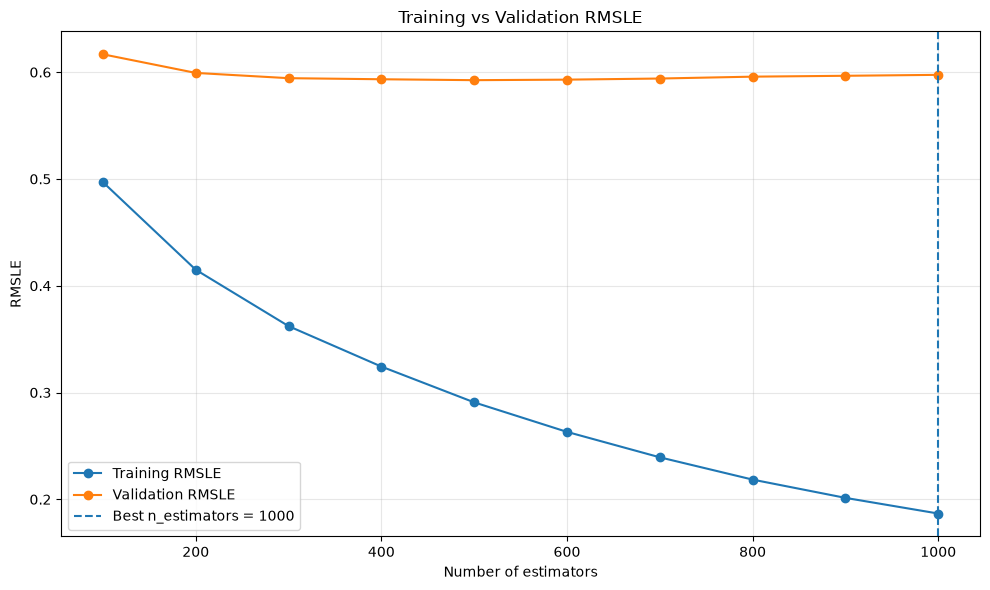

Saved: /Users/kaushiksathyanathsingh/Documents/ML project/Regression/training_vs_validation_mse.png


In [11]:
# 11. Plot training and validation RMSLE

plt.figure(figsize=(10, 6))

plt.plot(
    curve_estimators,
    curve_train_rmsle,
    marker='o',
    label='Training RMSLE'
)

plt.plot(
    curve_estimators,
    curve_val_rmsle,
    marker='o',
    label='Validation RMSLE'
)

plt.axvline(
    best_n_estimators,
    linestyle='--',
    label=f'Best n_estimators = {best_n_estimators}'
)

plt.xlabel('Number of estimators')
plt.ylabel('RMSLE')
plt.title('Training vs Validation RMSLE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(PLOT_PATH, dpi=150)
plt.show()

print("Saved:", PLOT_PATH)


In [12]:
# 12. Train final model on all training data
final_model = get_model(best_params)
final_model.fit(X_train, y_train)

print("Final model trained.")


Final model trained.


In [13]:
# 13. Test error, if test labels are available

if 'Rented Bike Count' in test_df.columns:
    # Model predicts log1p(demand), so transform back first.
    test_pred_log = final_model.predict(X_test)
    test_preds = np.expm1(test_pred_log)
    test_preds = np.clip(test_preds, 0, None)

    y_test = test_df['Rented Bike Count'].values

    test_rmsle = np.sqrt(
        mean_squared_log_error(y_test, test_preds)
    )

    test_mse = mean_squared_error(y_test, test_preds)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, test_preds)
    test_r2 = r2_score(y_test, test_preds)

    print("TRUE TEST ERROR")
    print(f"Test RMSLE : {test_rmsle:.6f}")
    print(f"Test MSE   : {test_mse:.2f}")
    print(f"Test RMSE  : {test_rmse:.2f}")
    print(f"Test MAE   : {test_mae:.2f}")
    print(f"Test R²    : {test_r2:.4f}")

else:
    print("test.csv has no 'Rented Bike Count'.")
    print("A true test error cannot be calculated.")
    print(f"5-fold CV validation RMSLE: {np.mean(val_rmsle):.6f}")


test.csv has no 'Rented Bike Count'.
A true test error cannot be calculated.
5-fold CV validation RMSLE: 0.597503


In [14]:
# 14. Generate submission

# Predict in log-space, then convert back to the original demand scale.
test_pred_log = final_model.predict(X_test)

test_preds = np.expm1(test_pred_log)
test_preds = np.clip(test_preds, 0, None)

test_preds_rounded = np.round(test_preds).astype(int)

if 'Kaggle_ID' in test_df.columns:
    sub_df = pd.DataFrame({
        'Kaggle_ID': test_df['Kaggle_ID'],
        'Rented Bike Count': test_preds_rounded
    })
else:
    sub_df = pd.DataFrame({
        'Rented Bike Count': test_preds_rounded
    })

sub_df.to_csv(SUB_PATH, index=False)

print("Saved submission:", SUB_PATH)
print(sub_df.head())


Saved submission: /Users/kaushiksathyanathsingh/Documents/ML project/Regression/submission.csv
   Kaggle_ID  Rented Bike Count
0          0                438
1          1                766
2          2                398
3          3                394
4          4                247
